# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target.

The features can be summarized as the following:

- **Clothing ID**: Integer categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive integer variable of the reviewer's age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high-level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable where `1` means recommended and `0` means not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv('data/reviews.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df.copy()

# Separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    stratify=y,
    random_state=27,
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (16597, 8), Test shape: (1845, 8)


# Your Work

## Data Exploration

Train class distribution:


,proportion
Recommended IND,
1,0.816232
0,0.183768


Missing values in training data (all should be 0 for this dataset):


,missing_count
Clothing ID,0
Age,0
Title,0
Review Text,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0


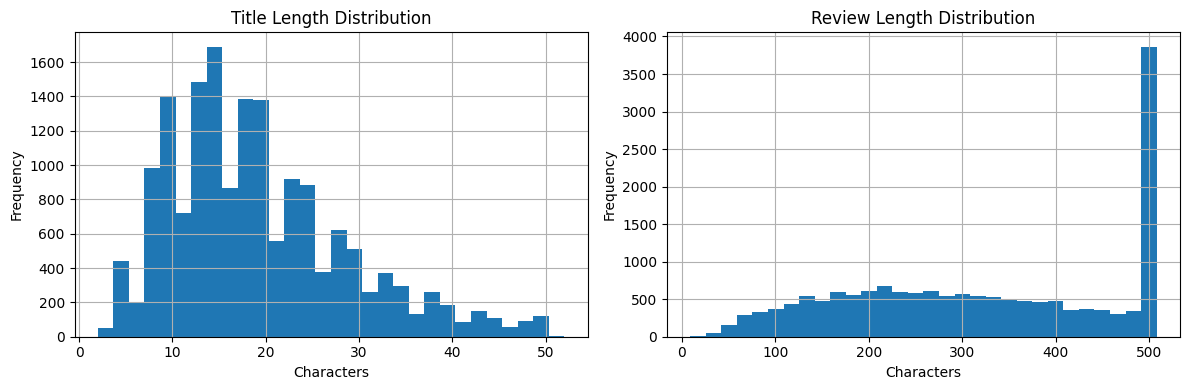

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print('Train class distribution:')
display(y_train.value_counts(normalize=True).rename('proportion').to_frame())

print('Missing values in training data (all should be 0 for this dataset):')
display(X_train.isna().sum().to_frame('missing_count'))

text_lengths = pd.DataFrame({
    'Title Length': X_train['Title'].str.len(),
    'Review Length': X_train['Review Text'].str.len(),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
text_lengths['Title Length'].hist(ax=axes[0], bins=30)
axes[0].set_title('Title Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

text_lengths['Review Length'].hist(ax=axes[1], bins=30)
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Building Pipeline

In [5]:
import re

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

numeric_features = ['Age', 'Positive Feedback Count']
categorical_features = ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']

def normalize_text(text):
    """Basic normalization used before tokenization in TF-IDF."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def make_text_pipeline(min_df=2, ngram_range=(1, 2), max_features=12000):
    return Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='')),
            ('flatten', FunctionTransformer(lambda col: col.squeeze(), validate=False)),
            (
                'tfidf',
                TfidfVectorizer(
                    preprocessor=normalize_text,
                    stop_words='english',
                    min_df=min_df,
                    ngram_range=ngram_range,
                    max_features=max_features,
                    sublinear_tf=True,
                ),
            ),
        ]
    )

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features),
        ('title_text', make_text_pipeline(min_df=1, ngram_range=(1, 2), max_features=3000), ['Title']),
        ('review_text', make_text_pipeline(min_df=2, ngram_range=(1, 2), max_features=15000), ['Review Text']),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(n_estimators=300, random_state=27, class_weight='balanced_subsample', n_jobs=-1)),
    ]
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Training Pipeline

,accuracy,precision,recall,f1
baseline,0.8775,0.881,0.9827,0.9291


Baseline classification report:
              precision    recall  f1-score   support

           0       0.84      0.41      0.55       339
           1       0.88      0.98      0.93      1506

    accuracy                           0.88      1845
   macro avg       0.86      0.70      0.74      1845
weighted avg       0.87      0.88      0.86      1845



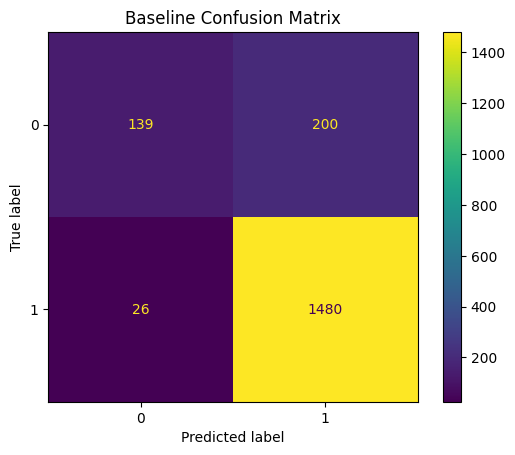

In [6]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

# Train baseline pipeline
model_pipeline.fit(X_train, y_train)
baseline_pred = model_pipeline.predict(X_test)

baseline_metrics = pd.DataFrame(
    {
        'accuracy': [accuracy_score(y_test, baseline_pred)],
        'precision': [precision_score(y_test, baseline_pred)],
        'recall': [recall_score(y_test, baseline_pred)],
        'f1': [f1_score(y_test, baseline_pred)],
    },
    index=['baseline'],
)
display(baseline_metrics.round(4))

print('Baseline classification report:')
print(classification_report(y_test, baseline_pred))

ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred)
plt.title('Baseline Confusion Matrix')
plt.show()

## Fine-Tuning Pipeline

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'preprocess__title_text__tfidf__ngram_range': [(1, 1), (1, 2)],
    'preprocess__review_text__tfidf__min_df': [2, 5],
    'model__max_depth': [None, 40],
    'model__min_samples_leaf': [1, 2],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=27)

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print('Best CV F1:', round(grid_search.best_score_, 4))
print('Best params:')
for key, value in grid_search.best_params_.items():
    print(f'  {key}: {value}')


Fitting 3 folds for each of 16 candidates, totalling 48 fits


/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/renan/Documents/Projects/udacity/data-science/project4/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of 

Best CV F1: 0.9364
Best params:
  model__max_depth: None
  model__min_samples_leaf: 2
  preprocess__review_text__tfidf__min_df: 2
  preprocess__title_text__tfidf__ngram_range: (1, 2)


,accuracy,precision,recall,f1
baseline,0.8775,0.881,0.9827,0.9291
tuned,0.8856,0.918,0.9442,0.9309


Tuned classification report:
              precision    recall  f1-score   support

           0       0.72      0.63      0.67       339
           1       0.92      0.94      0.93      1506

    accuracy                           0.89      1845
   macro avg       0.82      0.78      0.80      1845
weighted avg       0.88      0.89      0.88      1845



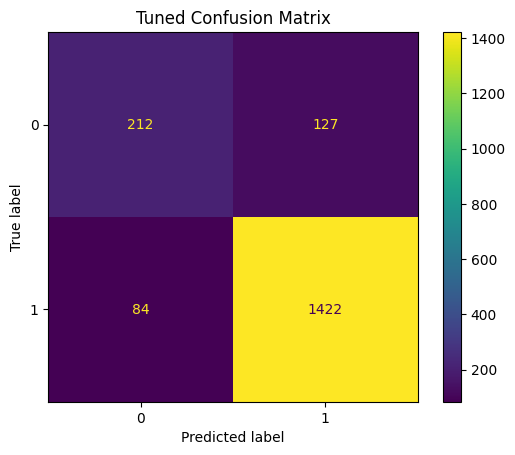

In [8]:
# Evaluate tuned model on held-out test data
tuned_pred = best_model.predict(X_test)

tuned_metrics = pd.DataFrame(
    {
        'accuracy': [accuracy_score(y_test, tuned_pred)],
        'precision': [precision_score(y_test, tuned_pred)],
        'recall': [recall_score(y_test, tuned_pred)],
        'f1': [f1_score(y_test, tuned_pred)],
    },
    index=['tuned'],
)

display(pd.concat([baseline_metrics, tuned_metrics]).round(4))

print('Tuned classification report:')
print(classification_report(y_test, tuned_pred))

ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred)
plt.title('Tuned Confusion Matrix')
plt.show()

### Final Notes
- The final model uses a single end-to-end pipeline that includes preprocessing, NLP feature extraction, and classification.
- Hyperparameter tuning is performed with cross-validation on training data only, then evaluated once on held-out test data.